# Graph maker
This part creates four comparative graphs between the simulation and the real system.

In [68]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
import os
from datetime import datetime

from package_DBR import *
from Package_Lab import *

In [69]:
With_MVD_MVI_MVP_MVFF = True

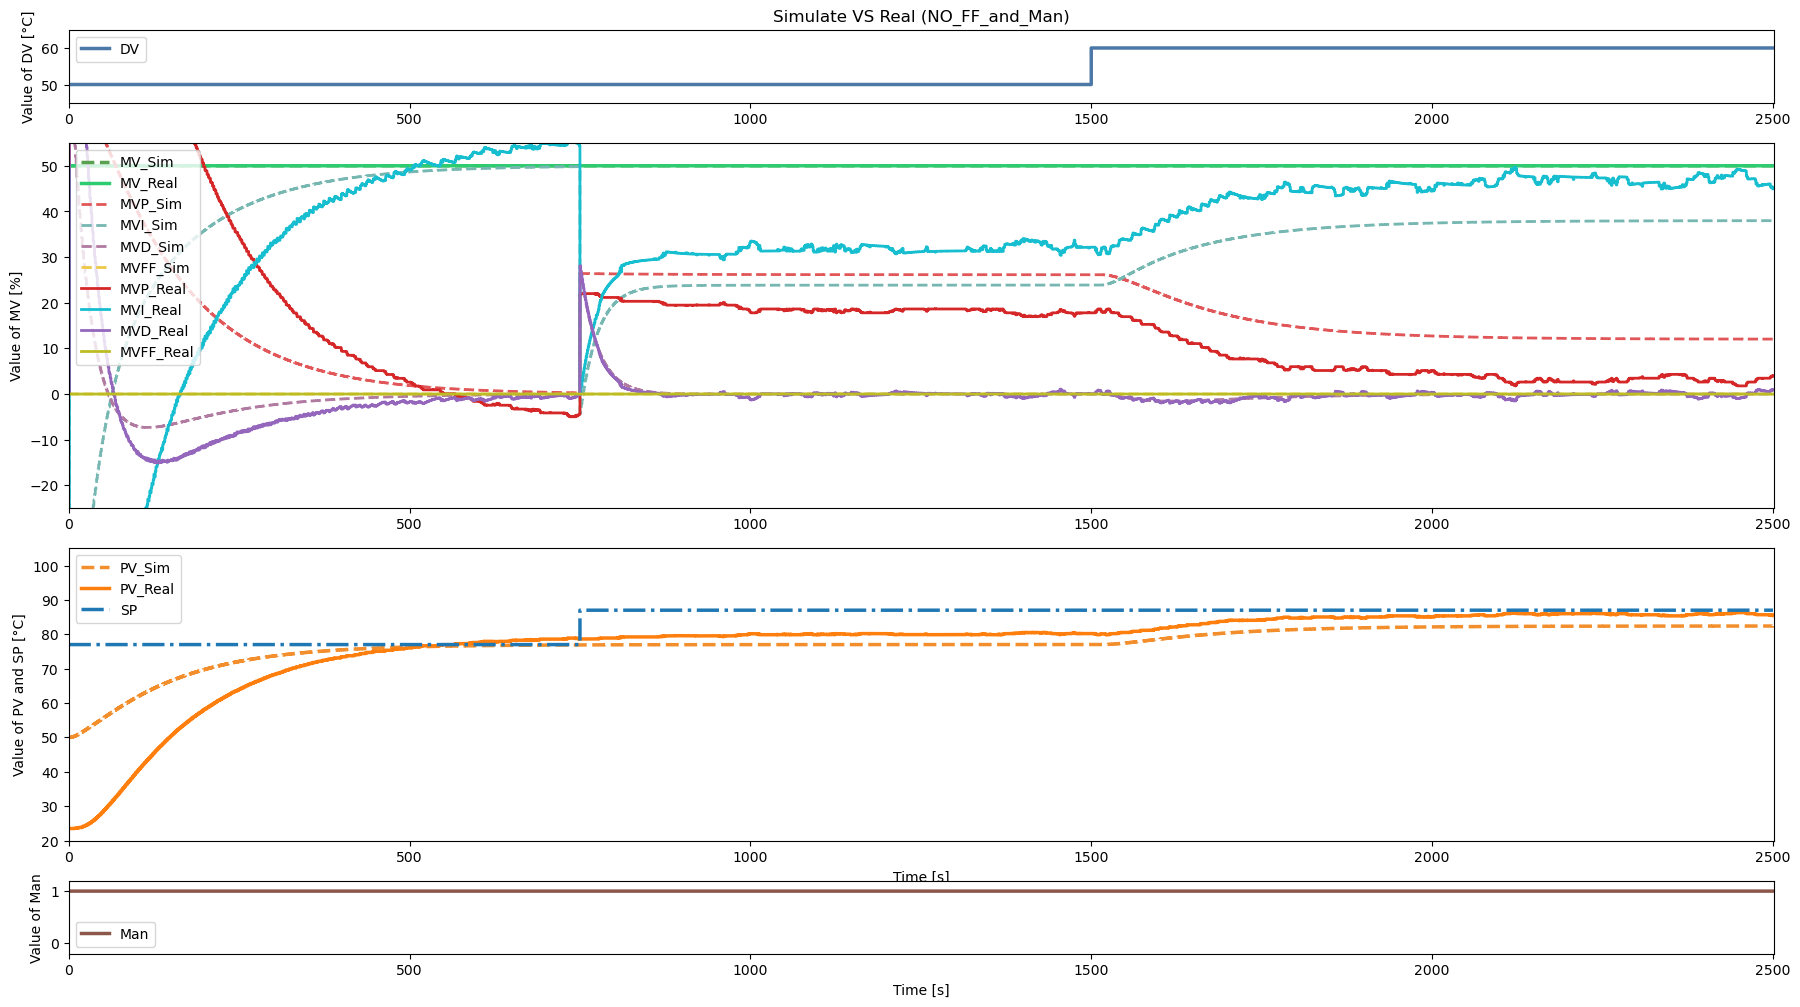

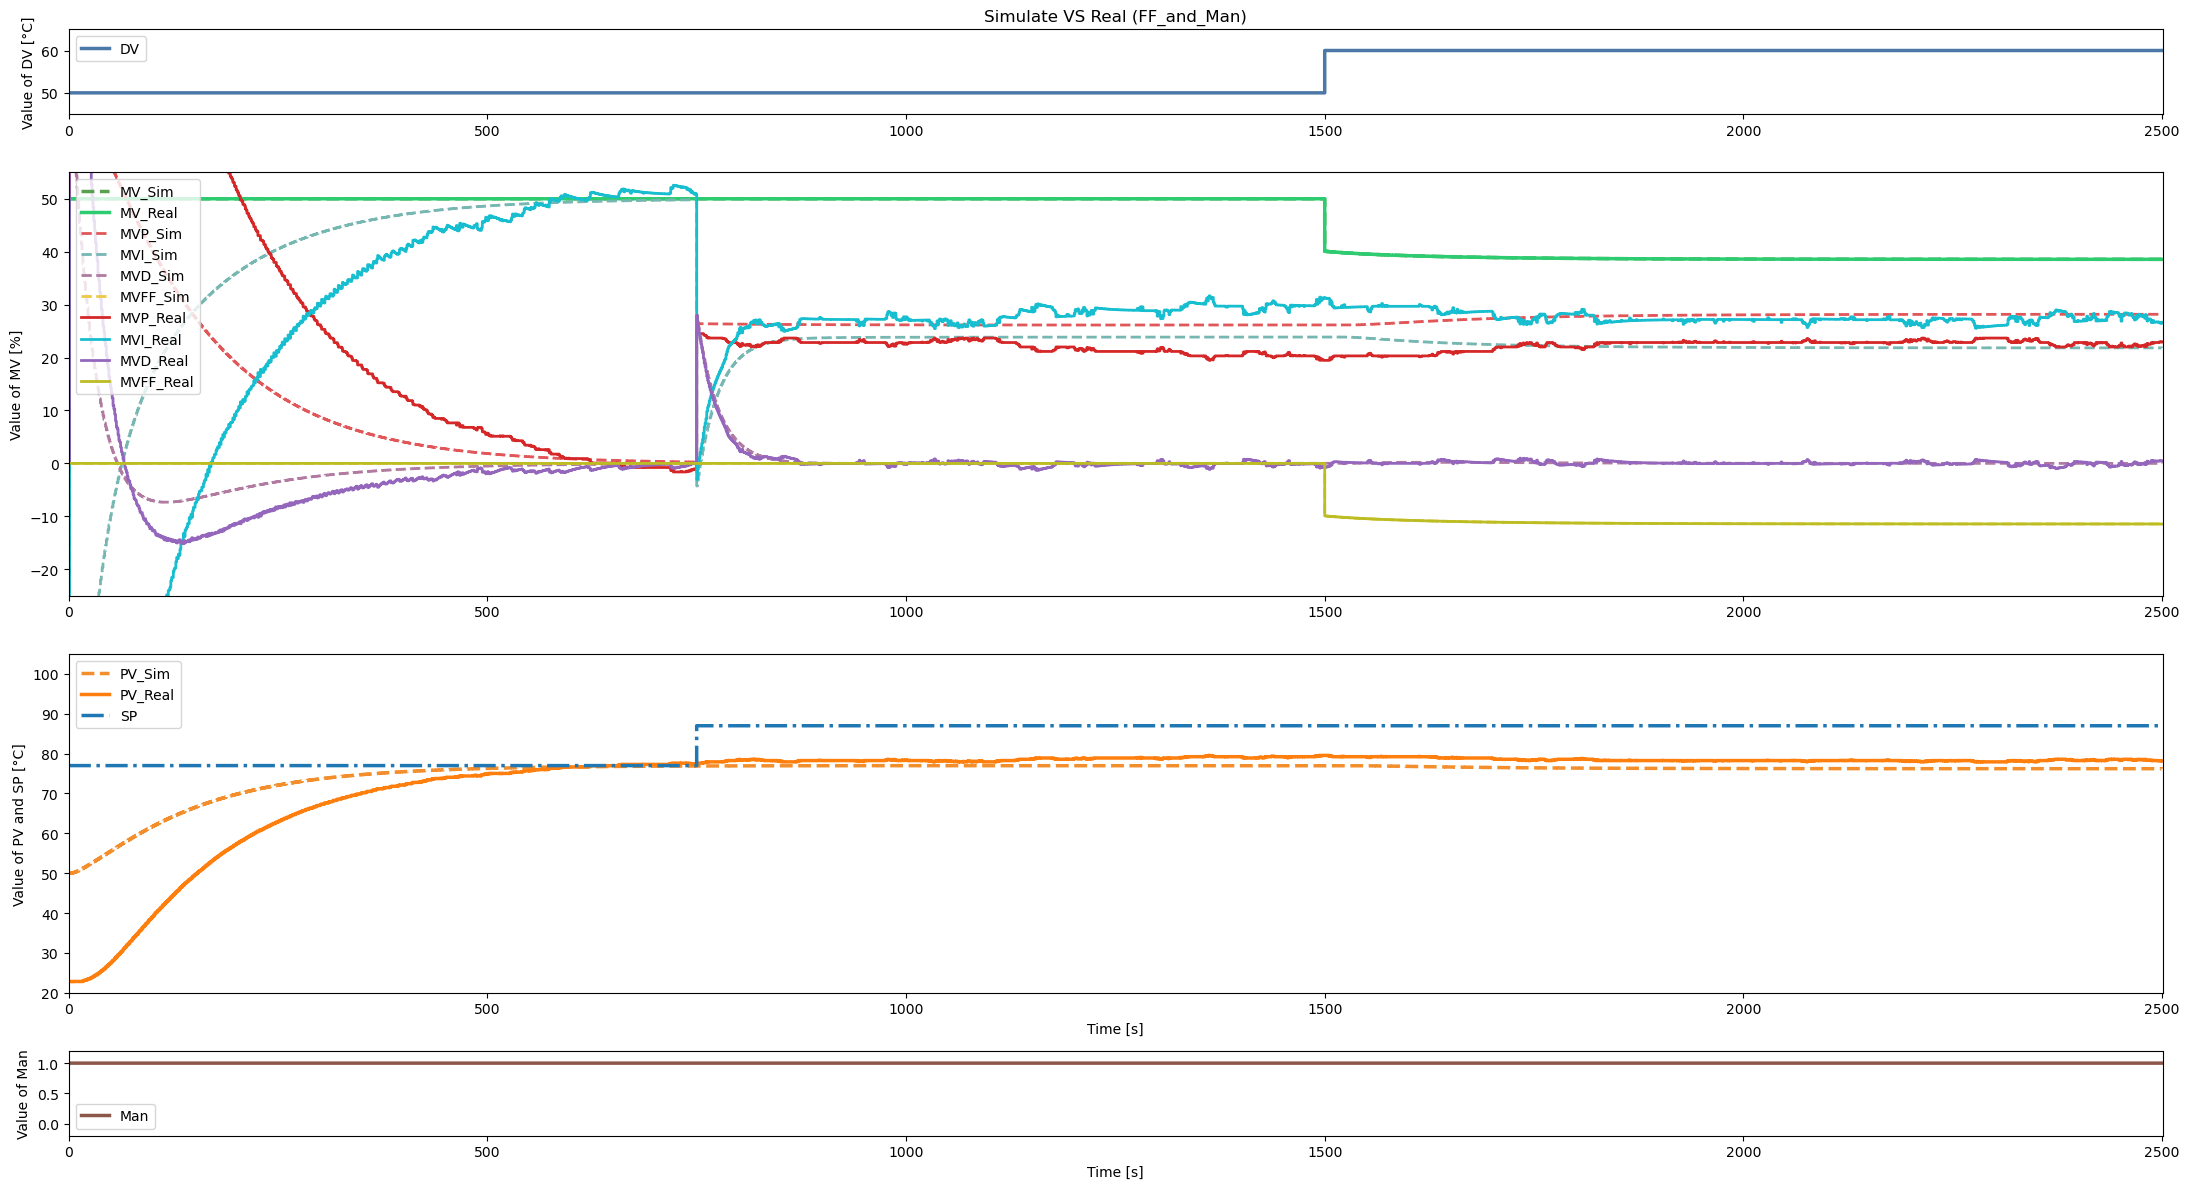

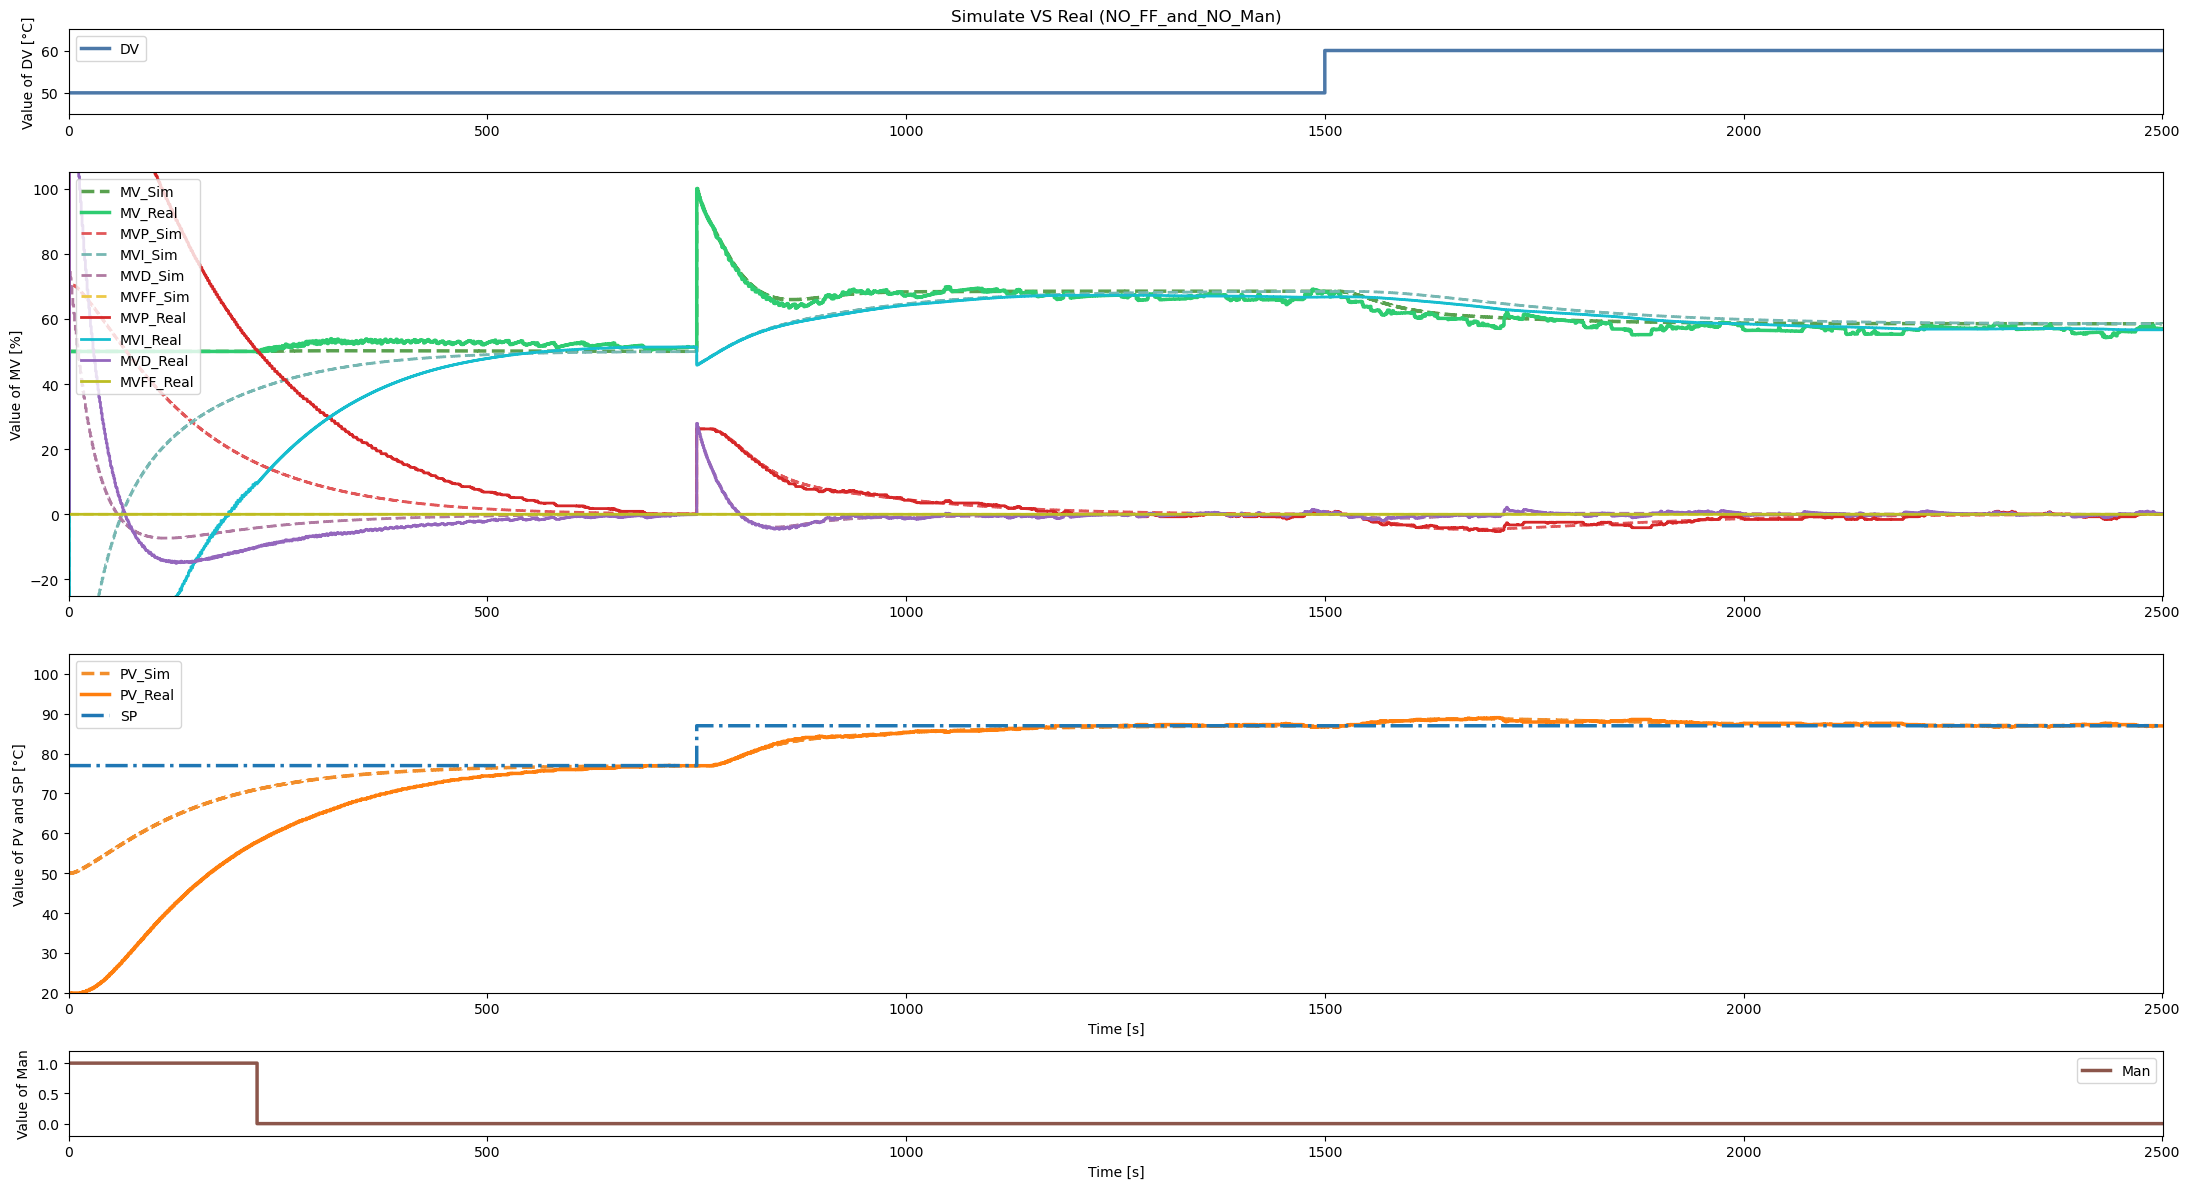

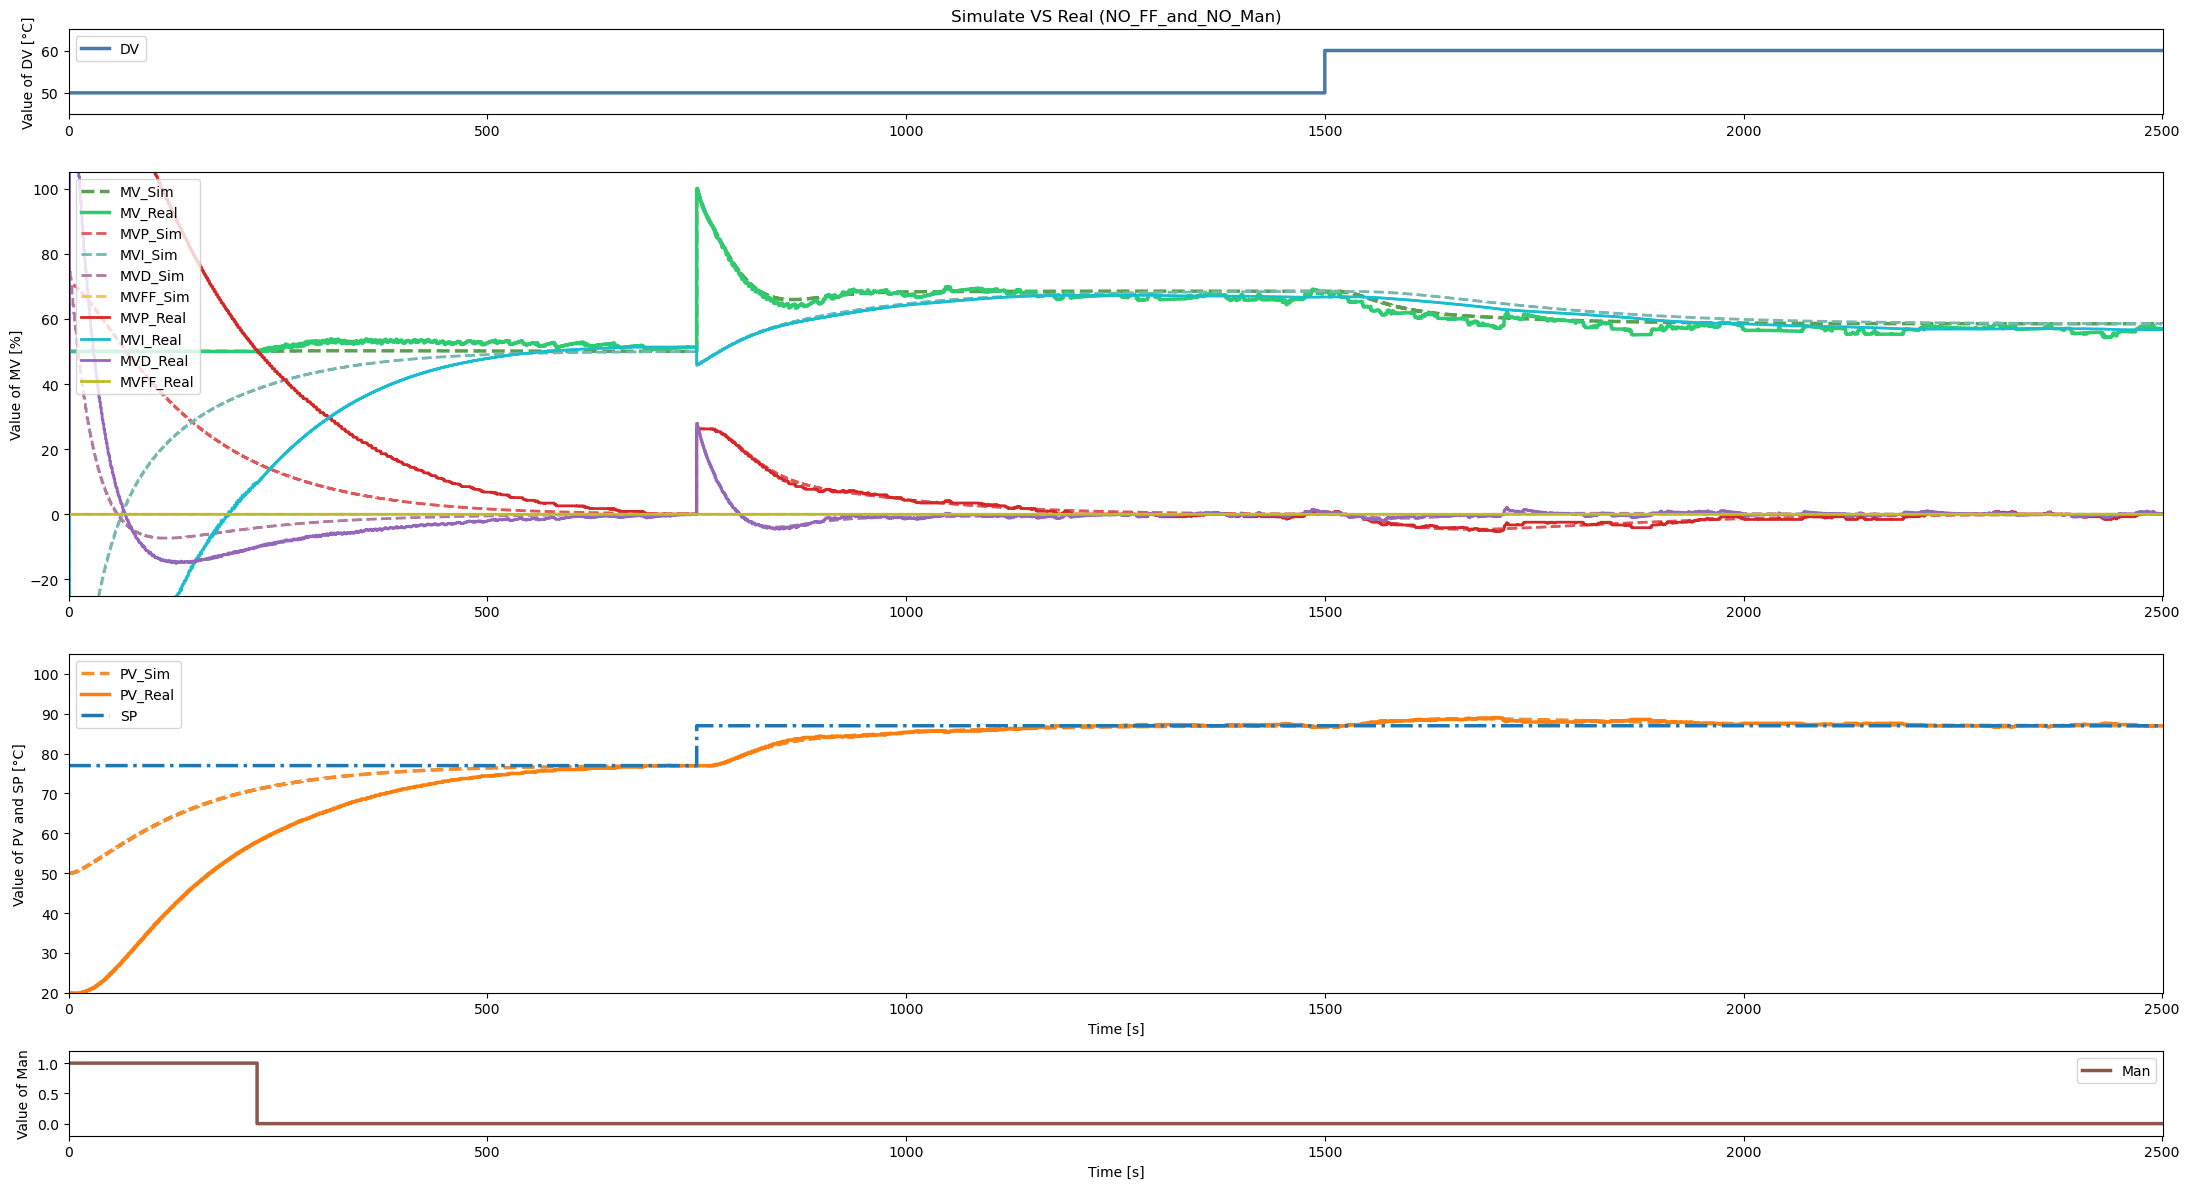

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(15,9),
                        gridspec_kw={'height_ratios': [1, 5, 4, 1]})
fig.set_figheight(12)
fig.set_figwidth(22)

# --- AX1 (DV) ---
l1, = ax1.step([0,1],[0,100],
               color="#4C78A8", linewidth=2.5, label='DV', where='post')

ax1.set_ylabel('Value of DV [°C]')
ax1.set_title('Real-time test')
ax1.legend(loc='best')


# --- AX2 (MV) ---
l2, = ax2.step([0,1],[0,100],
               color="#59A14F", linewidth=2.5, linestyle='--', label='MV_Sim', where='post')

l10, = ax2.step([0,1],[0,100],
                color="#2ECC71", linewidth=2.5, linestyle='-', label='MV_Real', where='post')

if With_MVD_MVI_MVP_MVFF == True:
    l6, = ax2.step([0,1],[0,100],
                   color="#E15759", linestyle='--', linewidth=2, label='MVP_Sim', where='post')
    l7, = ax2.step([0,1],[0,100],
                   color="#76B7B2", linestyle='--', linewidth=2, label='MVI_Sim', where='post')
    l8, = ax2.step([0,1],[0,100],
                   color="#B07AA1", linestyle='--', linewidth=2, label='MVD_Sim', where='post')
    l9, = ax2.step([0,1],[0,100],
                   color="#EDC948", linestyle='--', linewidth=2, label='MVFF_Sim', where='post')

    l11, = ax2.step([0,1],[0,100],
                    color="#D62728", linestyle='-', linewidth=2, label='MVP_Real', where='post')
    l12, = ax2.step([0,1],[0,100],
                    color="#17BECF", linestyle='-', linewidth=2, label='MVI_Real', where='post')
    l13, = ax2.step([0,1],[0,100],
                    color="#9467BD", linestyle='-', linewidth=2, label='MVD_Real', where='post')
    l14, = ax2.step([0,1],[0,100],
                    color="#BCBD22", linestyle='-', linewidth=2, label='MVFF_Real', where='post')

ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='best')


# --- AX3 (PV & SP) ---
l3, = ax3.step([0,1],[0,100],
               color="#F28E2B", linewidth=2.5, linestyle='--', label='PV_Sim', where='post')

l15, = ax3.step([0,1],[0,100],
                color="#FF7F0E", linewidth=2.5, linestyle='-', label='PV_Real', where='post')

l4, = ax3.step([0,1],[0,100],
               color="#1F77B4", linewidth=2.5, linestyle='-.', label='SP', where='post')

ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Value of PV and SP [°C]')
ax3.legend(loc='best')


# --- AX4 (Man) ---
l5, = ax4.step([0,1],[0,100],
               color="#8C564B", linewidth=2.5, linestyle='-', label='Man', where='post')

ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Value of Man')
ax4.legend(loc='best')

TSim = 2500
Ts = 1
N = int(TSim/Ts) + 1

PV0 = 77

for Scenario in range(1,4):

    # Path
    if Scenario == 1: # 1 - NO FF and Man
        name = "NO_FF_and_Man"
        FF = False
        MVFFPath = {0:0 , TSim: 0}
        SPPath = {0: PV0, 750:87, TSim: 87}
        DVPath = {0: 50, 1500:60, TSim: 60}
        ManPath = {0: True, TSim:True}
        MVManPath = {0: 50, TSim: 50}
        Real_Path = "CLP_experiment_on_2026-03-28-10h31(NO_FF_and_Man).txt"

    elif Scenario == 2: # 2 - FF and Man
        name = "FF_and_Man"
        FF = True
        SPPath = {0: PV0, 750:87, TSim: 87}
        DVPath = {0: 50, 1500:60, TSim: 60}
        ManPath = {0: True, TSim:True}
        MVManPath = {0: 50, TSim: 50}
        Real_Path = "CLP_experiment_on_2026-03-28-09h32(FF_and_Man).txt"

    elif Scenario == 3: # 3 - NO FF and NO Man
        name = "NO_FF_and_NO_Man"
        FF = False
        MVFFPath = {0:0 , TSim: 0}
        SPPath = {0: PV0, 750:87, TSim: 87}
        DVPath = {0: 50, 1500:60, TSim: 60}
        ManPath = {0: True,225:False, TSim:False}
        MVManPath = {0: 50, 225: 0 , TSim: 0}
        Real_Path = "CLP_experiment_on_2026-03-28-08h30(NO_FF_and_NO_Man).txt"

    elif Scenario == 4: # 4 - FF and NO Man
        name = "FF_and_NO_Man"
        FF = True
        SPPath = {0: PV0, 750:87, TSim: 87}
        DVPath = {0: 50, 1500:60, TSim: 60}
        ManPath = {0: True,225:False, TSim:False}
        MVManPath = {0: 50, 225: 0 , TSim: 0}
        Real_Path = "CLP_experiment_on_2026-03-26-18h50(FF_and_NO_Man).txt"

    titleName = Real_Path.split('.')[0]    
    data = pd.read_csv('Data/' + Real_Path)

    MV_Real = data['MV'].values
    MVP_Real = data['MVP'].values
    MVI_Real = data['MVI'].values
    MVD_Real = data['MVD'].values
    MVFF_Real = data['MVFF'].values
    PV_Real = data['PV'].values

    t = []
    SP = []

    MV = []
    MVDelay = []

    DV = []
    MVFFDelay = []
    MVFF_FLL = []
    MVFF = []

    MVDelayp = []
    PV1p = []
    PV2p = []

    MVDelayd = []
    PV1d = []
    PV2d = []

    MVMan = []
    MVP = []
    MVI = []
    MVD = []
    PV = []
    PV_P = []
    PV_D = []
    E = []
    Man = []

    # Parameters
    DV0 = 50
    MV0 = 50
    gamma = 0.9
    Kc = 0
    Ti = 0
    Td = 0
    alpha = 0.9
    MVMin = 0
    MVMax = 100
    ManFF = False
    Kd = 0.618599605156834
    Kp = 0.540610574655048
    T1d = 147.5486385332903
    T2d = 36.22565494631446
    T1p = 130.5026136090156
    T2p = 35.46518028608689
    Thetap = 14.348568183245677
    Thetad = 13.351904889062693

    for i in range(0,N):

        t.append(i*Ts)
        SelectPath_RT(SPPath,t,SP)
        SelectPath_RT(DVPath,t,DV)
        SelectPath_RT(ManPath,t,Man)
        SelectPath_RT(MVManPath,t,MVMan)

        #MVFF
        if FF == True:
            Delay_RT(DV-DV0*np.ones_like(DV),max(0,Thetad-Thetap),Ts,MVFFDelay)
            LL_RT(MVFFDelay,-Kd/Kp,Ts,T1p,T1d,MVFF_FLL)
            LL_RT(MVFF_FLL,1,Ts,T2p,T2d,MVFF,0)
        else:
            SelectPath_RT(MVFFPath,t,MVFF)

        Kc, Ti, Td = IMC_TUNING(Kp,gamma,T1p,T2p,max(0,Thetad-Thetap))

        PID_RT(SP,PV,Man,MVMan,MVFF,Kc,Ti,Td,alpha,Ts,MVMin,MVMax,MV,MVP,MVI,MVD,E,ManFF,PV0)

        #P(s)
        Delay_RT(MV, Thetap, Ts, MVDelayp,MV0)
        FO_RT(MVDelayp, Kp, T1p, Ts, PV1p, 0)
        FO_RT(PV1p, 1, T2p, Ts, PV2p, 0)

        #D(s)
        Delay_RT(DV - DV0*np.ones_like(DV),Thetad,Ts,MVDelayd,DV0)
        FO_RT(MVDelayd, Kp, T1d, Ts, PV1d, 0)
        FO_RT(PV1d, 1, T2d, Ts, PV2d, 0)

        PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

    ax1.set_title('Simulate VS Real ('+ (name) +')')

    l1.set_data(t,DV)
    l2.set_data(t,MV)
    l10.set_data(t,MV_Real)
    l3.set_data(t,PV)
    l15.set_data(t,PV_Real)
    l4.set_data(t,SP)
    l5.set_data(t,Man)
    if With_MVD_MVI_MVP_MVFF == True:
        l6.set_data(t,MVP)
        l7.set_data(t,MVI)
        l8.set_data(t,MVD)
        l9.set_data(t,MVFF)
        l11.set_data(t,MVP_Real)
        l12.set_data(t,MVI_Real)
        l13.set_data(t,MVD_Real)
        l14.set_data(t,MVFF_Real)

    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)

    ax1.set_ylim(myRound(np.min(DV),5)-5, myRound(np.max(DV),5)+5)
    ax2.set_ylim(-25, myRound(np.max(MV_Real),5)+10)
    ax3.set_ylim(20, 105)
    ax4.set_ylim(-0.2, 1.2)

    display(fig)

    now = datetime.now()
    date_time = now.strftime("%Y-%m-%d-%Hh%M")

    if not os.path.exists('Plots'):
        os.makedirs('Plots')

    fig.tight_layout()

    titleName = 'comparative_graph' + date_time+ '('+name+')'
    fig.savefig(os.path.join('Plots', titleName + '.png'), transparent=True)
    fig.savefig(os.path.join('Plots', titleName + '.pdf'), transparent=True)
